# 05 Basic Tabular Model Comparison

Establish an untuned baseline comparison using the same data, features, preprocessing, target, and validation observations for every model.

Models:

1. Median baseline
2. Linear Regression
3. Random Forest Regressor
4. Gradient Boosting Regressor

The test dataset remains untouched in this notebook.

## Setup

In [1]:
from gc import collect
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TRAIN_SAMPLE_ROWS = 500_000
VALIDATION_SAMPLE_ROWS = 300_000

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Load Fixed Training and Validation Data

In [2]:
def representative_sample(
    frame: pd.DataFrame,
    sample_rows: int,
    random_state: int,
) -> pd.DataFrame:
    if len(frame) <= sample_rows:
        return frame.copy()

    sample_fraction = sample_rows / len(frame)
    sampled = frame.groupby(
        ["site_id", "month", "primary_use"],
        observed=True,
        group_keys=False,
    ).sample(frac=sample_fraction, random_state=random_state)

    if len(sampled) > sample_rows:
        sampled = sampled.sample(n=sample_rows, random_state=random_state)
    elif len(sampled) < sample_rows:
        remaining = frame.loc[~frame.index.isin(sampled.index)]
        additional = remaining.sample(
            n=sample_rows - len(sampled),
            random_state=random_state,
        )
        sampled = pd.concat([sampled, additional], ignore_index=False)

    return sampled.sort_values("timestamp").reset_index(drop=True)


train_pool = pd.read_parquet(modeling_dir / "model_train.parquet")
validation_pool = pd.read_parquet(modeling_dir / "model_validation.parquet")

train_data = representative_sample(
    train_pool,
    TRAIN_SAMPLE_ROWS,
    RANDOM_STATE,
)
validation_data = representative_sample(
    validation_pool,
    VALIDATION_SAMPLE_ROWS,
    RANDOM_STATE,
)

sampling_summary = pd.DataFrame(
    [
        {
            "dataset": "training",
            "pool_rows": len(train_pool),
            "sample_rows": len(train_data),
            "start": train_data["timestamp"].min(),
            "end": train_data["timestamp"].max(),
        },
        {
            "dataset": "validation",
            "pool_rows": len(validation_pool),
            "sample_rows": len(validation_data),
            "start": validation_data["timestamp"].min(),
            "end": validation_data["timestamp"].max(),
        },
    ]
)

del train_pool, validation_pool
collect()

sampling_summary

,dataset,pool_rows,sample_rows,start,end
0,training,8395591,500000,2016-01-01,2016-09-12 23:00:00
1,validation,1843685,300000,2016-09-13,2016-11-06 23:00:00


## Feature Set and Preprocessing

In [3]:
def add_modeling_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["log_square_feet"] = np.log1p(result["square_feet"])
    result["building_age"] = (2016 - result["year_built"]).clip(lower=0)
    return result


train_data = add_modeling_features(train_data)
validation_data = add_modeling_features(validation_data)

numeric_features = [
    "log_square_feet",
    "building_age",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]
categorical_features = ["site_id", "primary_use"]
feature_columns = numeric_features + categorical_features
target_column = "meter_reading"

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
        ),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

X_train = preprocessor.fit_transform(train_data[feature_columns]).astype(
    "float32"
)
X_validation = preprocessor.transform(
    validation_data[feature_columns]
).astype("float32")
y_train = train_data[target_column].to_numpy(dtype="float64")
y_validation = validation_data[target_column].to_numpy(dtype="float64")

X_train.shape, X_validation.shape

((500000, 45), (300000, 45))

## Evaluation Helper

In [4]:
def regression_metrics(
    model_name: str,
    y_true: np.ndarray,
    predictions: np.ndarray,
    fit_seconds: float,
) -> dict:
    predictions = np.clip(predictions, a_min=0, a_max=None)
    return {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_true, predictions)),
        "mae": mean_absolute_error(y_true, predictions),
        "r2": r2_score(y_true, predictions),
        "rmsle": np.sqrt(mean_squared_log_error(y_true, predictions)),
        "fit_seconds": fit_seconds,
    }

## Train the Untuned Models

In [5]:
basic_models = {
    "Median Baseline": DummyRegressor(strategy="median"),
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
    ),
}

metric_rows = []
validation_predictions = {}

for model_name, model in basic_models.items():
    print(f"Training {model_name}...")
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - start

    predictions = np.clip(
        model.predict(X_validation),
        a_min=0,
        a_max=None,
    )
    validation_predictions[model_name] = predictions
    metric_rows.append(
        regression_metrics(
            model_name,
            y_validation,
            predictions,
            fit_seconds,
        )
    )

basic_metrics = (
    pd.DataFrame(metric_rows)
    .sort_values("rmse")
    .reset_index(drop=True)
)
basic_metrics.to_csv(
    reports_dir / "basic_tabular_validation_metrics.csv",
    index=False,
)

basic_metrics

Training Median Baseline...
Training Linear Regression...
Training Random Forest Regressor...
Training Gradient Boosting Regressor...


,model,rmse,mae,r2,rmsle,fit_seconds
0,Random Forest Regressor,179.602784,33.302590,0.754937,0.701704,86.248862
1,Gradient Boosting Regressor,224.760713,95.502974,0.616212,1.253040,81.373661
2,Linear Regression,320.293173,187.111380,0.220625,1.810480,0.308787
3,Median Baseline,382.036478,155.819121,-0.108819,1.630294,0.006826


## Basic Model Comparison

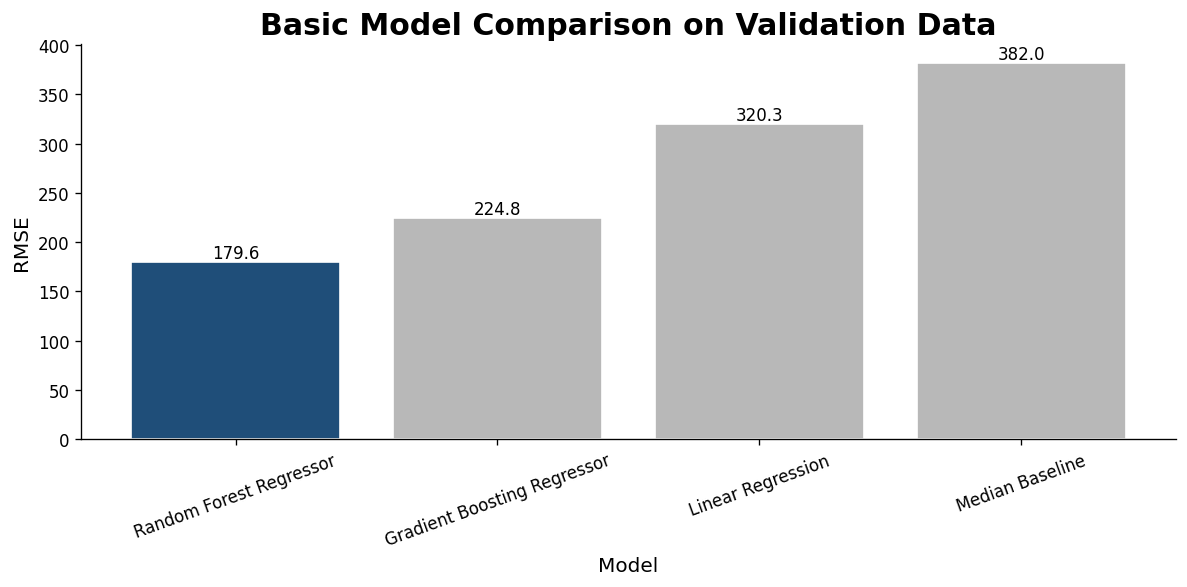

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

best_model = basic_metrics.loc[basic_metrics["rmse"].idxmin(), "model"]
colors = [
    "#1f4e79" if model == best_model else "#b8b8b8"
    for model in basic_metrics["model"]
]
bars = ax.bar(
    basic_metrics["model"],
    basic_metrics["rmse"],
    color=colors,
    edgecolor="white",
)

ax.set_title("Basic Model Comparison on Validation Data", fontsize=18, weight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.tick_params(axis="x", rotation=20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for bar, value in zip(bars, basic_metrics["rmse"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
fig.savefig(
    figures_dir / "basic_tabular_model_comparison.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Interpretation Rule

These are validation results from untuned models. Preserve this table as the baseline. Tune only the tree models in a later notebook using the same training and validation samples. Do not evaluate the test dataset until the final model and settings have been selected.